In [ ]:
#3b
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import tensorflow as tf

In [ ]:

df = tf.keras.datasets.fashion_mnist

In [ ]:
(X_train, y_train), (X_test, y_test) = df.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


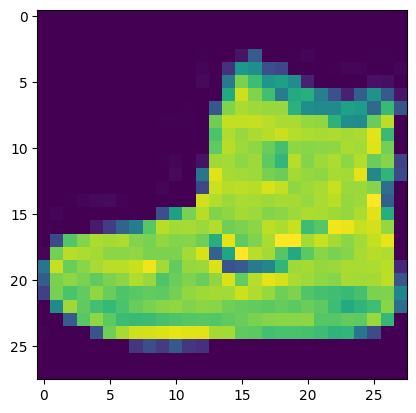

In [ ]:
plt.imshow(X_train[0])
plt.show()

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape = (28,28,1)
    )
)
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    X_train,
    y_train,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 21ms/step - accuracy: 0.8586 - loss: 0.4009
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9019 - loss: 0.2681
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 21ms/step - accuracy: 0.9166 - loss: 0.2230
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9297 - loss: 0.1898
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9401 - loss: 0.1604


In [ ]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [ ]:
predicted_class = np.argmax(y_pred[0])
print(predicted_class)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(class_names[predicted_class])

9
Ankle boot


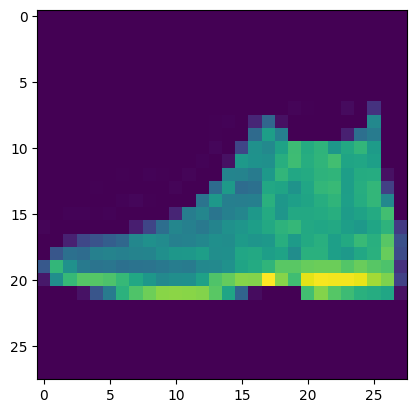

In [ ]:
plt.imshow(X_test[0].reshape(28,28))

plt.show()

In [ ]:
#3a untested

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling
# Define standard image size and batch size
img_height = 128
img_width = 128
batch_size = 32
data_dir = "./Potato" # Make sure your extracted dataset folder is named this

print("Loading Training Data:")
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

print("\nLoading Validation Data:")
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

# Extract the class names (the names of your subfolders)
class_names = train_ds.class_names
print(f"\nClasses found: {class_names}")
num_classes = len(class_names)

model = Sequential()

# 1. Normalization Layer
model.add(Rescaling(1./255, input_shape=(img_height, img_width, 3)))

# 2. First Convolutional Block
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 3. Second Convolutional Block
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 4. Third Convolutional Block
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 5. Flatten and Dense Layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

model.summary()

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=10
)

In [ ]:
for images, labels in val_ds.take(1):
    test_image = images[0]
    actual_label = labels[0]

    # Model expects a batch, so we expand dimensions
    img_array = tf.expand_dims(test_image, 0)

    # Make prediction
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions[0])

    # Display the image
    plt.imshow(test_image.numpy().astype("uint8"))
    plt.title(f"Actual: {class_names[actual_label]}\nPredicted: {class_names[predicted_class]}")
    plt.axis("off")
    plt.show()

In [ ]:
"""# Convolutional Neural Network (CNN)

A Convolutional Neural Network (CNN) is a type of Deep Neural Network specially designed for:

* image processing
* computer vision
* pattern recognition

Applications:

* face recognition
* object detection
* medical imaging
* plant disease detection
* fashion classification

---

# Why CNN Instead of Normal Neural Network?

Normal neural networks struggle with images because:

* images have huge number of pixels
* spatial relationships are important

CNN automatically learns:

* edges
* textures
* shapes
* patterns

from images.

---

# Basic CNN Architecture

```text id="cjlwm1"
Input Image → Convolution → ReLU → Pooling → Fully Connected Layer → Output
```

---

# Main Components of CNN

| Layer                 | Purpose              |
| --------------------- | -------------------- |
| Convolution Layer     | Feature extraction   |
| ReLU Layer            | Adds non-linearity   |
| Pooling Layer         | Reduces dimensions   |
| Fully Connected Layer | Final classification |

---

# What is Convolution?

Convolution means:

> Applying filters/kernels to image to detect features.

Example features:

* edges
* corners
* textures

---

# Convolution Operation

Feature\ Map = Image * Kernel

Where:

* kernel/filter slides over image
* important features extracted

---

# Kernel / Filter

Small matrix used for feature extraction.

Example:

```text id="cjlwm2"
3×3 filter
```

---

# ReLU Activation Function

Introduces non-linearity.

f(x)=\max(0,x)

Advantages:

* fast computation
* avoids vanishing gradient
* improves training speed

---

# Pooling Layer

Pooling reduces image size.

Types:

| Type            | Purpose             |
| --------------- | ------------------- |
| Max Pooling     | Takes maximum value |
| Average Pooling | Takes average       |

---

# Max Pooling

Example:

```text id="cjlwm3"
4×4 image → 2×2 image
```

Benefits:

* reduces computation
* reduces overfitting
* keeps important features

---

# Fully Connected Layer

Final classification layer.

Uses extracted features to predict output class.

---

# Softmax Function

Used in multiclass classification.

P(y_i)=\frac{e^{z_i}}{\sum e^{z_j}}

Converts outputs into probabilities.

---

# OPTION 1: Plant Disease Detection using CNN

---

# Problem Statement

Design a system to detect plant diseases using leaf images.

Input:

```text id="cjlwm4"
Leaf Image
```

Output:

```text id="cjlwm5"
Healthy / Diseased Plant
```

---

# Dataset

Plant disease datasets usually contain:

* healthy leaves
* infected leaves
* multiple disease categories

Common datasets:

* PlantVillage Dataset
* Kaggle Plant Disease Dataset

---

# Workflow

1. Collect leaf images
2. Preprocess images
3. Train CNN
4. Predict disease class

---

# Image Preprocessing

Images resized before training.

Example:

```python id="cjlwm6"
image_size = (128,128)
```

---

# Data Augmentation

Creates modified copies of images.

Techniques:

* rotation
* flipping
* zooming

Purpose:

* increase dataset size
* reduce overfitting

---

# CNN Model Example

```python id="cjlwm7"
Conv2D → ReLU → MaxPooling
Conv2D → ReLU → MaxPooling
Flatten
Dense
Softmax
```

---

# Output Layer

If there are 5 diseases:

```python id="cjlwm8"
Dense(5, activation='softmax')
```

---

# Loss Function

Uses:

## Categorical Cross Entropy

L=-\sum y\log(\hat y)

---

# Applications

* smart agriculture
* crop monitoring
* automatic disease diagnosis
* yield improvement

---

# Expected Output

```text id="cjlwm9"
Predicted Disease: Leaf Blight
Accuracy: 96%
```

---

# Advantages

* automatic detection
* fast diagnosis
* high accuracy
* reduces manual inspection

---

# OPTION 2: Fashion MNIST Classification using CNN

---

# What is Fashion MNIST?

Fashion MNIST is a dataset of clothing images.

Contains:

* 70,000 grayscale images
* 28×28 pixels
* 10 fashion categories

Created as replacement for handwritten digit MNIST dataset.

---

# Categories in Fashion MNIST

| Label | Clothing Type |
| ----- | ------------- |
| 0     | T-shirt/top   |
| 1     | Trouser       |
| 2     | Pullover      |
| 3     | Dress         |
| 4     | Coat          |
| 5     | Sandal        |
| 6     | Shirt         |
| 7     | Sneaker       |
| 8     | Bag           |
| 9     | Ankle boot    |

---

# Goal

Input:

```text id="cjlwma"
Fashion image
```

Output:

```text id="cjlwmb"
Predicted clothing category
```

---

# Workflow

1. Load Fashion MNIST dataset
2. Normalize images
3. Build CNN model
4. Train CNN
5. Classify clothing image

---

# Image Normalization

Pixel values scaled between 0 and 1.

Formula:

x_{norm}=\frac{x}{255}

Benefits:

* faster convergence
* stable training

---

# CNN Architecture Example

```python id="cjlwmc"
Conv2D(32)
ReLU
MaxPooling

Conv2D(64)
ReLU
MaxPooling

Flatten
Dense(128)
Dense(10, activation='softmax')
```

---

# Flatten Layer

Converts 2D feature maps into 1D vector.

Needed before fully connected layer.

---

# Output Layer

10 neurons because dataset has 10 classes.

```python id="cjlwmd"
Dense(10, activation='softmax')
```

---

# Training Process

```python id="cjlwme"
model.fit(X_train, y_train, epochs=10)
```

---

# Epoch

One complete pass through training dataset.

---

# Optimizer

Most commonly used:

## Adam Optimizer

Advantages:

* adaptive learning rate
* fast convergence
* efficient training

---

# Evaluation Metrics

| Metric   | Purpose             |
| -------- | ------------------- |
| Accuracy | Correct predictions |
| Loss     | Prediction error    |

---

# Accuracy Formula

Accuracy=\frac{Correct\ Predictions}{Total\ Predictions}

---

# Expected Output

```text id="cjlwmf"
Predicted Class: Sneaker
Accuracy: 92%
```

---

# Applications of Fashion Classification

* e-commerce
* recommendation systems
* automated tagging
* inventory management

---

# Advantages of CNN

* automatic feature extraction
* high image classification accuracy
* parameter sharing reduces complexity
* works well on large image datasets

---

# Limitations of CNN

* computationally expensive
* requires large datasets
* training can be slow
* needs GPU for large models

---

# Overfitting in CNN

Occurs when model memorizes training images.

Solutions:

* dropout
* data augmentation
* regularization

---

# Dropout

Randomly disables neurons during training.

Helps improve generalization.

---

# Difference Between ANN and CNN

| ANN               | CNN                    |
| ----------------- | ---------------------- |
| General purpose   | Specialized for images |
| Fully connected   | Uses convolution       |
| More parameters   | Fewer parameters       |
| Slower for images | Efficient for images   |

---

# Important Viva Questions

---

## What is CNN?

CNN is a deep learning model mainly used for image processing.

---

## Why CNN for images?

Because CNN automatically extracts spatial image features.

---

## What is convolution?

Applying filters over image to extract features.

---

## What is pooling?

Reducing feature map dimensions.

---

## What is ReLU?

Activation function returning:

\max(0,x)

---

## What is softmax?

Function converting outputs into probabilities.

---

## What is Fashion MNIST?

Dataset containing images of clothing categories.

---

## What is data augmentation?

Generating modified copies of images to improve training.

---

## What is flatten layer?

Converts 2D feature maps into 1D vector.

---

## Why use CNN over ANN?

CNN is more efficient and accurate for image data.

---

## What causes overfitting?

Model memorizes training data instead of learning general patterns.

---

## Applications of CNN?

* image recognition
* medical imaging
* autonomous vehicles
* agriculture
* facial recognition
"""